<h2><font color="#004D7F" size=6>Módulo 2. Análisis de datos</font></h2>



<h1><font color="#004D7F" size=5>3. Visualización de datos</font></h1>

<br><br>
<div style="text-align: right">
<font color="#004D7F" size=3>Manuel Castillo-Cara</font><br>
<font color="#004D7F" size=3>Machine Learning con Python</font><br>

---

<h2><font color="#004D7F" size=5>Índice</font></h2>
<a id="indice"></a>

* [1. Introducción](#section1)
    * [1.1. Cargar el conjunto de datos](#section11)
* [2. Visualización Univariable](#section2)
    * [2.1. Histogramas](#section21)
    * [2.2. Densidad](#section22)
    * [2.3. Boxplots](#section23)
* [3. Visualización Multivariable](#section3)
    * [3.1. Matriz de correlación](#section31)
    * [3.2. Matriz de dispersión](#section32)
    * [3.3. Matriz de dispersión por clase](#section33)
    * [3.4. Boxplot por clase](#section34)

In [1]:
# Permite ajustar la anchura de la parte útil de la libreta (reduce los márgenes)
from IPython.core.display import display, HTML
display(HTML("<style>.container{ width:98% }</style>"))

C:\Users\57300\AppData\Local\Temp\ipykernel_19384\1126351303.py:2: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


---

<a id="section1"></a>
# <font color="#004D7F"> 1. Introducción</font>

Lo primero que debemos realizar a la hora de trabajar con machine learning es visualizar nuestros datos para conocer su comportamiento y distribución. Esta primera observación de datos posibilita aprender más sobre ellos siendo la forma más rápida y útil de conocer qué técnicas son las más adecuadas en _pre_ y _pos_ procesamiento. En este sentido en esta tercera sección trabajaremos:
* Cómo crear gráficos para entender cada atributo de manera independiente.
* Cómo crear gráficos para entender las relaciones entre los diferentes atributos.

Los gráficos de las relaciones entre los atributos pueden darnos una idea de los atributos que pueden ser redundantes, los métodos de remuestreo que pueden ser necesarios y, en última instancia, la dificultad de un problema de predicción. Para ello, la fase de visualización puede dividirse en las siguientes partes:
* **Visualización univariable**: Cuando queremos visualizar un atributo de manera independiente a los demás.
* **Visualización multivariable**: Cuando queremos visualizar la interacción entre los diferentes atributos de nuestro conjunto de datos.

<a id="section11"></a>
## <font color="#004D7F">1.1. Cargar el conjunto de datos</font>

Para esta práctica vamos a cargar el conjunto de datos de Pima Indian Diabetes para hacer observaciones con las funciones de estadística descriptiva.

In [2]:
import pandas as pd 
filename='./data/pima-indians-diabetes.csv'
names=['preg','plas','pres','skin','test','mass','pedi','age','class']
data=pd.read_csv(filename,names=names)

<div style="text-align: right"> <font size=5>
    <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a>
</font></div>

---

<a id="section2"></a>
# <font color="#004D7F"> 2. Visualización Univariable</font>

Como se ha comentado anteriormente, las gráficas univariable nos permiten visualizar los atributos individuales sin interacciones; las cuales, el objetivo principal de las mismas es aprender algo sobre la distribución, la tendencia y la propagación de cada atributo.

A continuación se describen las más relevantes.

<a id="section21"></a>
## <font color="#004D7F">2.1. Histogramas </font>

A partir de la forma de los contenedores, puede tener una idea rápida de si un atributo es gaussiano, sesgado o incluso tiene una distribución exponencial. También puede ayudarlo a ver posibles valores atípicos, por lo que [Matplotlib](https://www.datacamp.com/community/tutorials/histograms-matplotlib) es una pontente librería de visualización de datos

C:\Users\57300\AppData\Local\Temp\ipykernel_19384\2708439012.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data.hist(ax = ax)


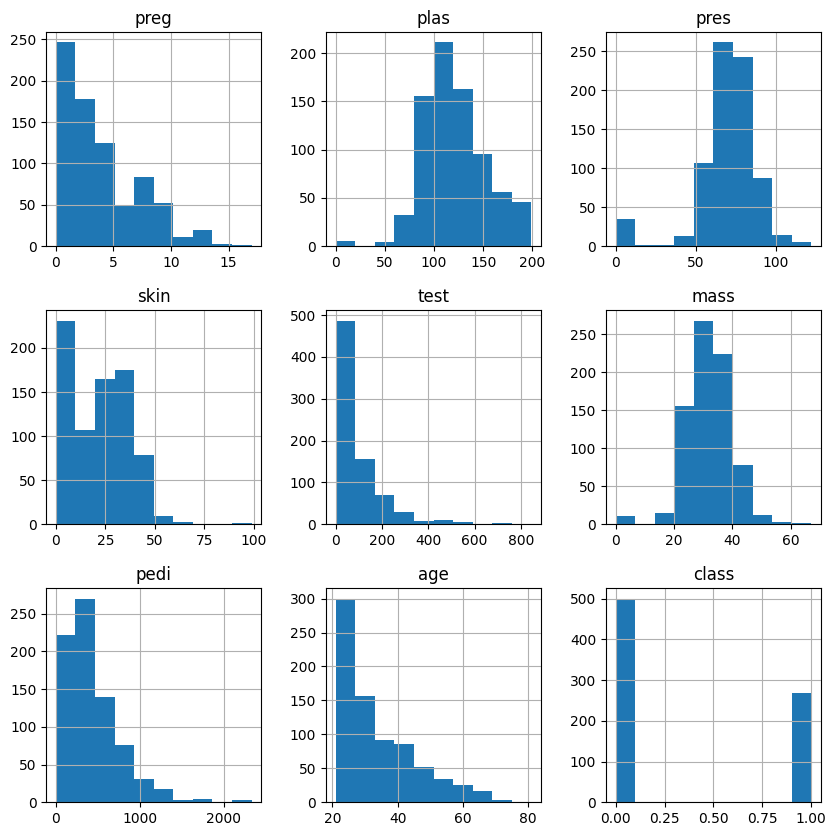

In [3]:

import matplotlib.pyplot as ptl
fig = ptl.figure(figsize = (10,10))
ax = fig.gca()
data.hist(ax = ax)
ptl.show()

Podemos ver que quizás los atributos `age`, `pedi` y `test` pueden tener una distribución exponencial. También podemos ver que quizás los atributos `mass`, `pres` y `plas` pueden tener una distribución gaussiana o casi gaussiana. Esto es interesante porque muchas técnicas de aprendizaje automático suponen una distribución univariada gaussiana en las variables de entrada.

Esta misma representación puede verse con el paquete [Seaborn](https://seaborn.pydata.org/tutorial/distributions.html). Seaborn es un paquete de visualización más profesional que Matplotlib, además de usar este por debajo. Podemos ver los Histogramas con una línea de densidad que nos muestra su distribución

<div class="alert alert-block alert-info">
    
<i class="fa fa-exclamation-circle" aria-hidden="true"></i>
En la nueva versión de seaborn ha quedado "deprecated" la función `distplot`. Para esta visualización se utilizará `histplot` tal y como lo pone ya en el caja de código.
</div> 

In [4]:
!pip install seaborn
# Univariate Histograms



[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: C:\Users\57300\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


<Axes: xlabel='class', ylabel='Density'>

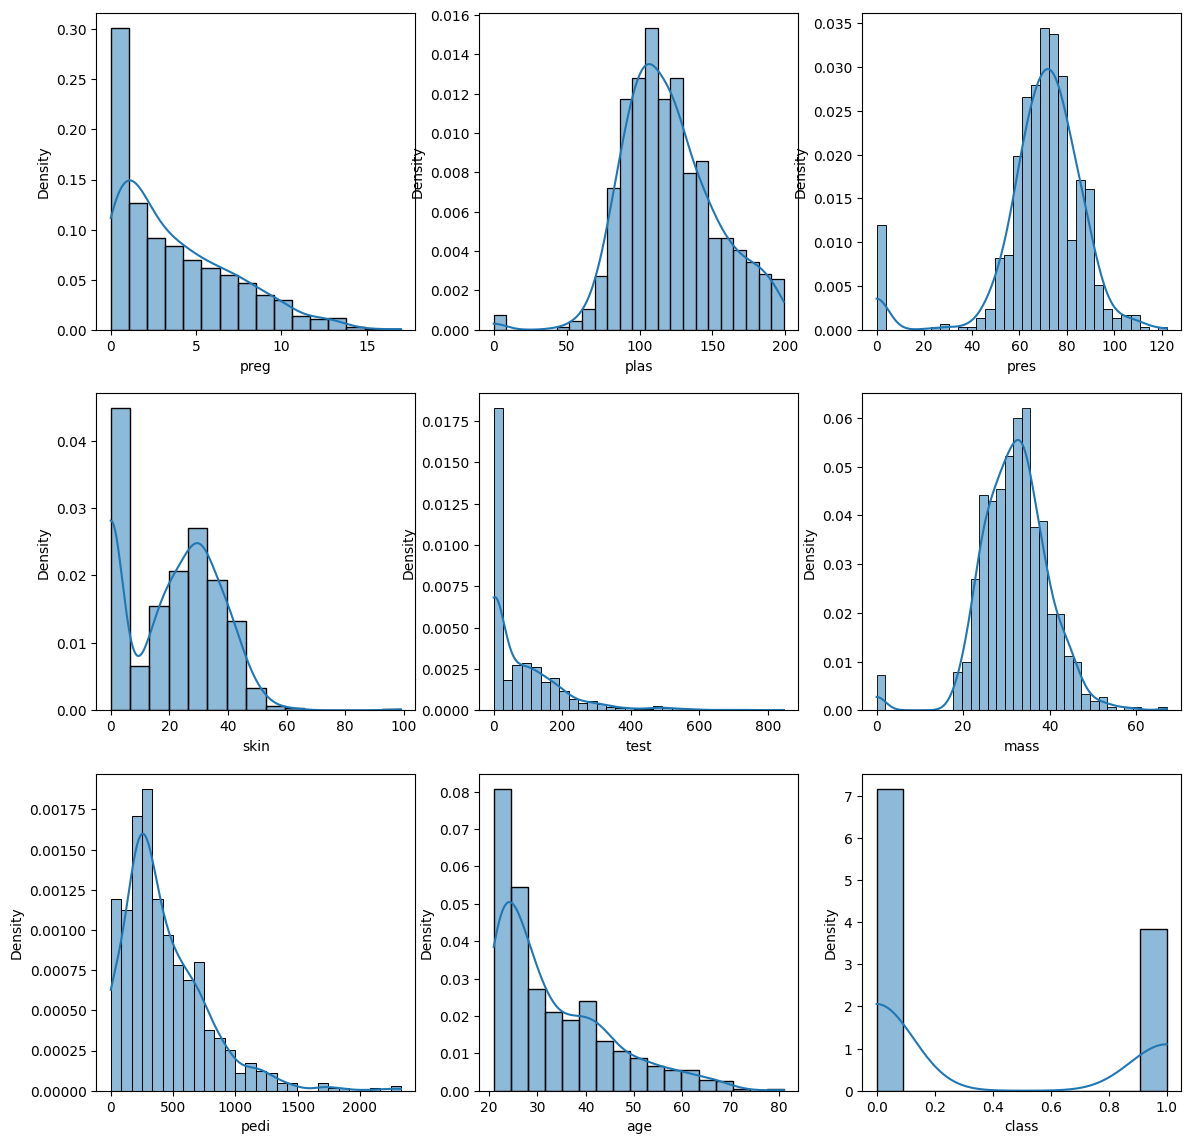

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
f, ax =plt.subplots(3,3,figsize=(14,14))
sns.histplot(data["preg"], ax=ax[0, 0], kde=True, stat="density")
sns.histplot(data["plas"], ax=ax[0, 1], kde=True, stat="density")
sns.histplot(data["pres"], ax=ax[0, 2], kde=True, stat="density")
sns.histplot(data["skin"], ax=ax[1, 0], kde=True, stat="density")
sns.histplot(data["test"], ax=ax[1, 1], kde=True, stat="density")
sns.histplot(data["mass"], ax=ax[1, 2], kde=True, stat="density")
sns.histplot(data["pedi"], ax=ax[2, 0], kde=True, stat="density")
sns.histplot(data["age"], ax=ax[2, 1], kde=True, stat="density")
sns.histplot(data["class"], ax=ax[2, 2], kde=True, stat="density")

<a id="section22"></a>
## <font color="#004D7F">2.2. Densidad </font>

Las gráficas se ven como un histograma abstracto con una curva suave dibujada a través de la parte superior de cada contenedor, al igual que su ojo intentó hacer con los histogramas. Podemos ver que la distribución de cada atributo es más clara que los histogramas

C:\Users\57300\AppData\Local\Temp\ipykernel_19384\2900687620.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data.plot(ax=ax, kind='density',subplots=True,layout=(3,3),sharex=False)


<function matplotlib.pyplot.show(close=None, block=None)>

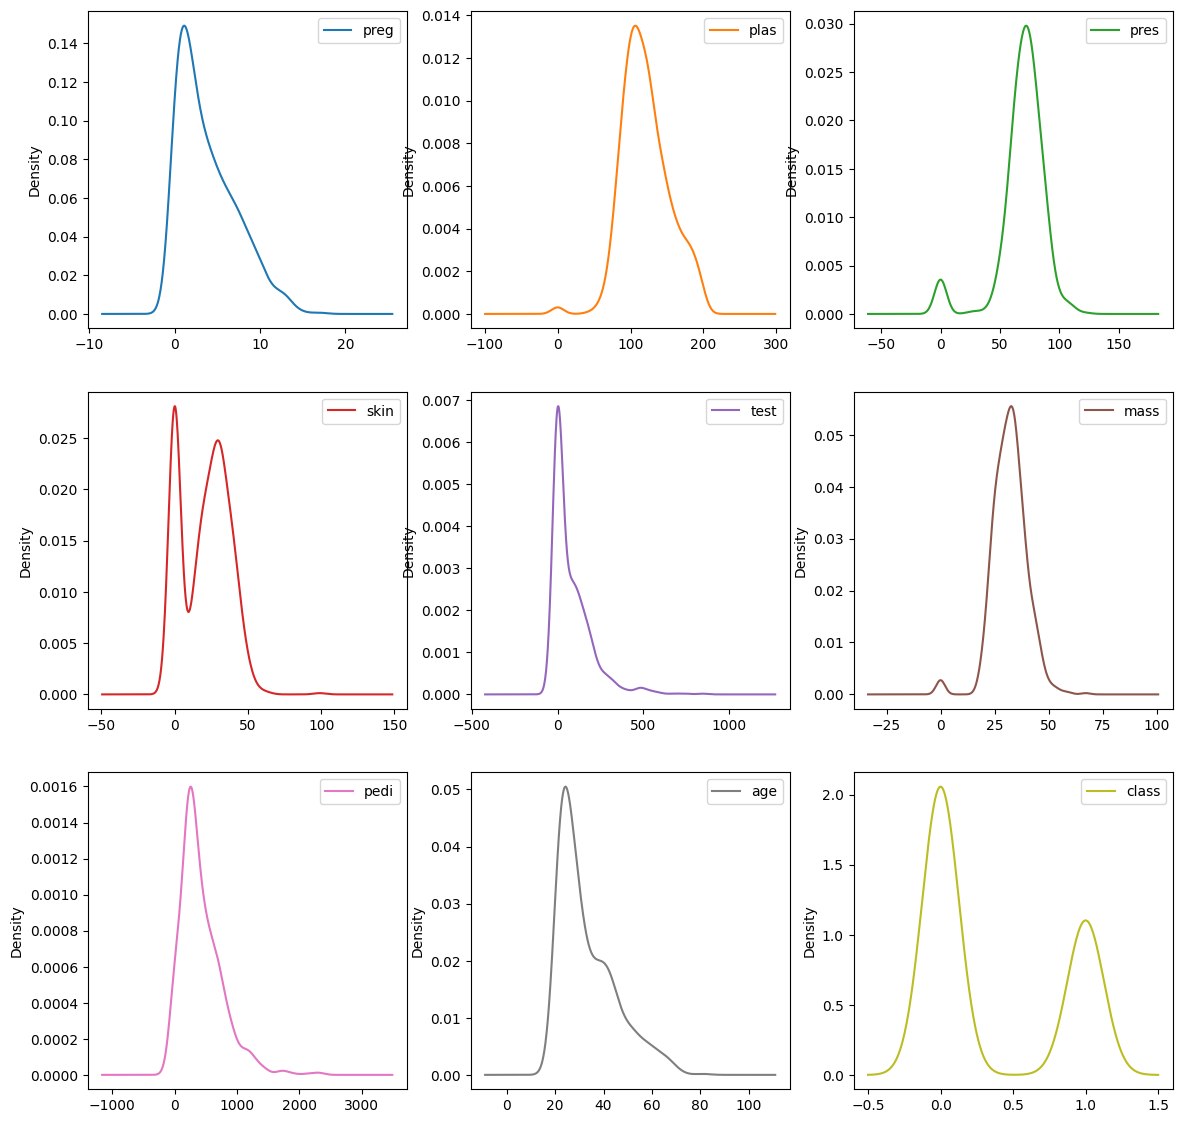

In [6]:
fig = plt.figure(figsize=(14,14))
ax=fig.gca()
data.plot(ax=ax, kind='density',subplots=True,layout=(3,3),sharex=False)
plt.show

Al igual que hemos visto antes podemos ver también el gráfico con la libreria Seaborn

<div class="alert alert-block alert-info">
    
<i class="fa fa-exclamation-circle" aria-hidden="true"></i>
En la nueva versión de seaborn ha quedado "deprecated" la función `distplot`. Para esta visualización se utilizará `kdeplot` tal y como lo pone ya en el caja de código.
</div> 

<Axes: xlabel='class', ylabel='Density'>

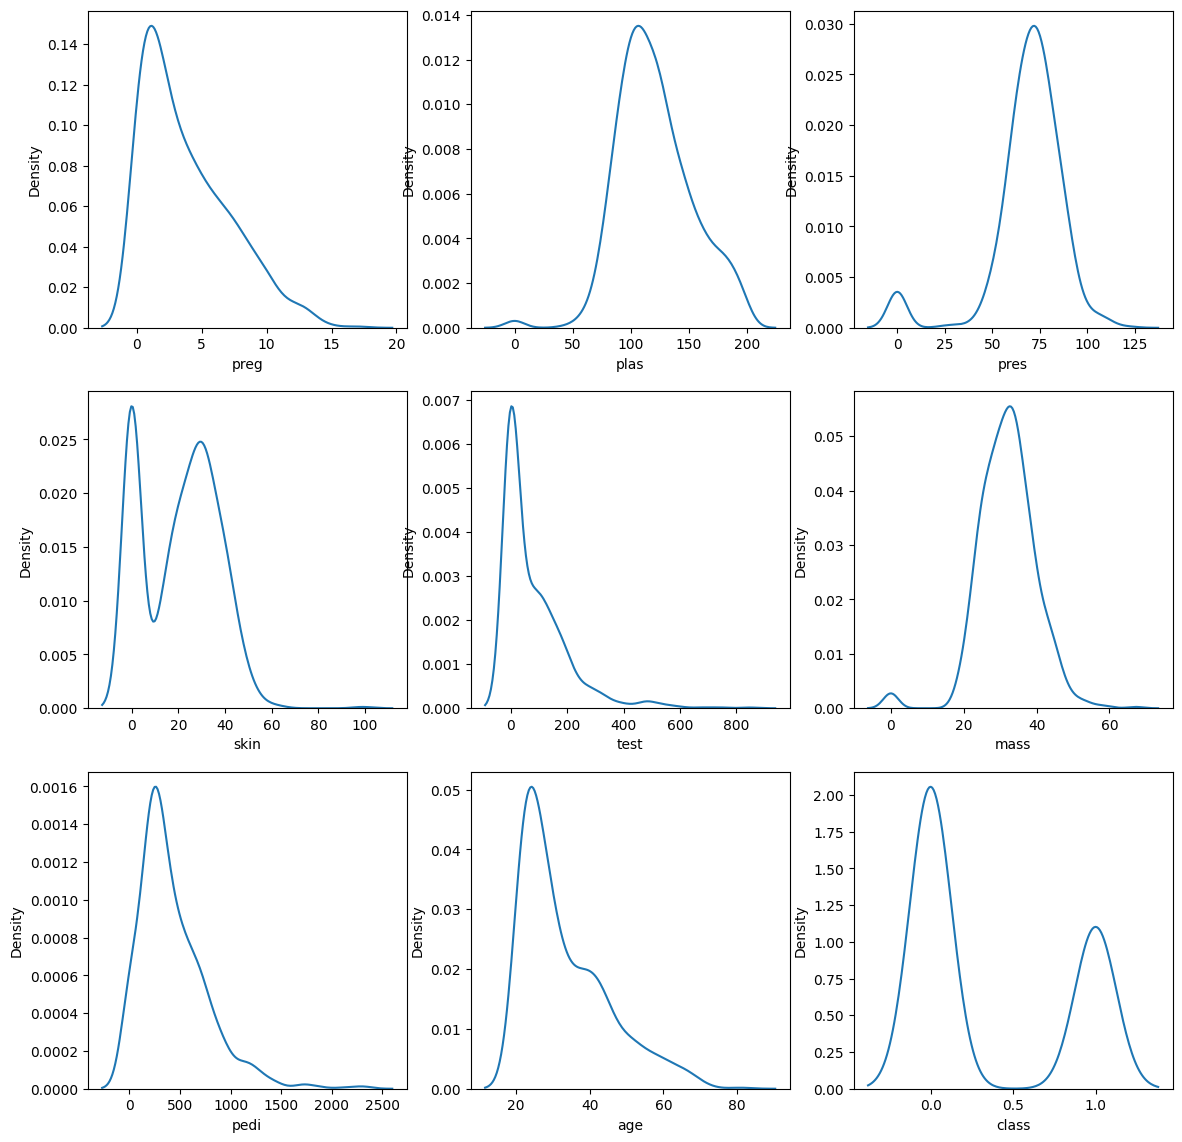

In [7]:
%matplotlib inline
# Univariate Histograms
f, axes = plt.subplots(3, 3, figsize = (14,14))
sns.kdeplot(data["preg"], ax = axes[0,0])
sns.kdeplot(data["plas"], ax = axes[0,1])
sns.kdeplot(data["pres"], ax = axes[0,2])
sns.kdeplot(data["skin"], ax = axes[1,0])
sns.kdeplot(data["test"], ax = axes[1,1])
sns.kdeplot(data["mass"], ax = axes[1,2])
sns.kdeplot(data["pedi"], ax = axes[2,0])
sns.kdeplot(data["age"], ax = axes[2,1])
sns.kdeplot(data["class"], ax = axes[2,2])

<a id="section23"></a>
## <font color="#004D7F">2.3. Boxplots </font>

Podemos ver que la extensión de los atributos es bastante diferente. Algunos como la `age`, `test` y `skin` parecen bastante sesgados hacia valores más pequeños.

C:\Users\57300\AppData\Local\Temp\ipykernel_19384\2827971863.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data.plot(ax=ax, kind='box', subplots=True,sharex=False,layout=(3,3))


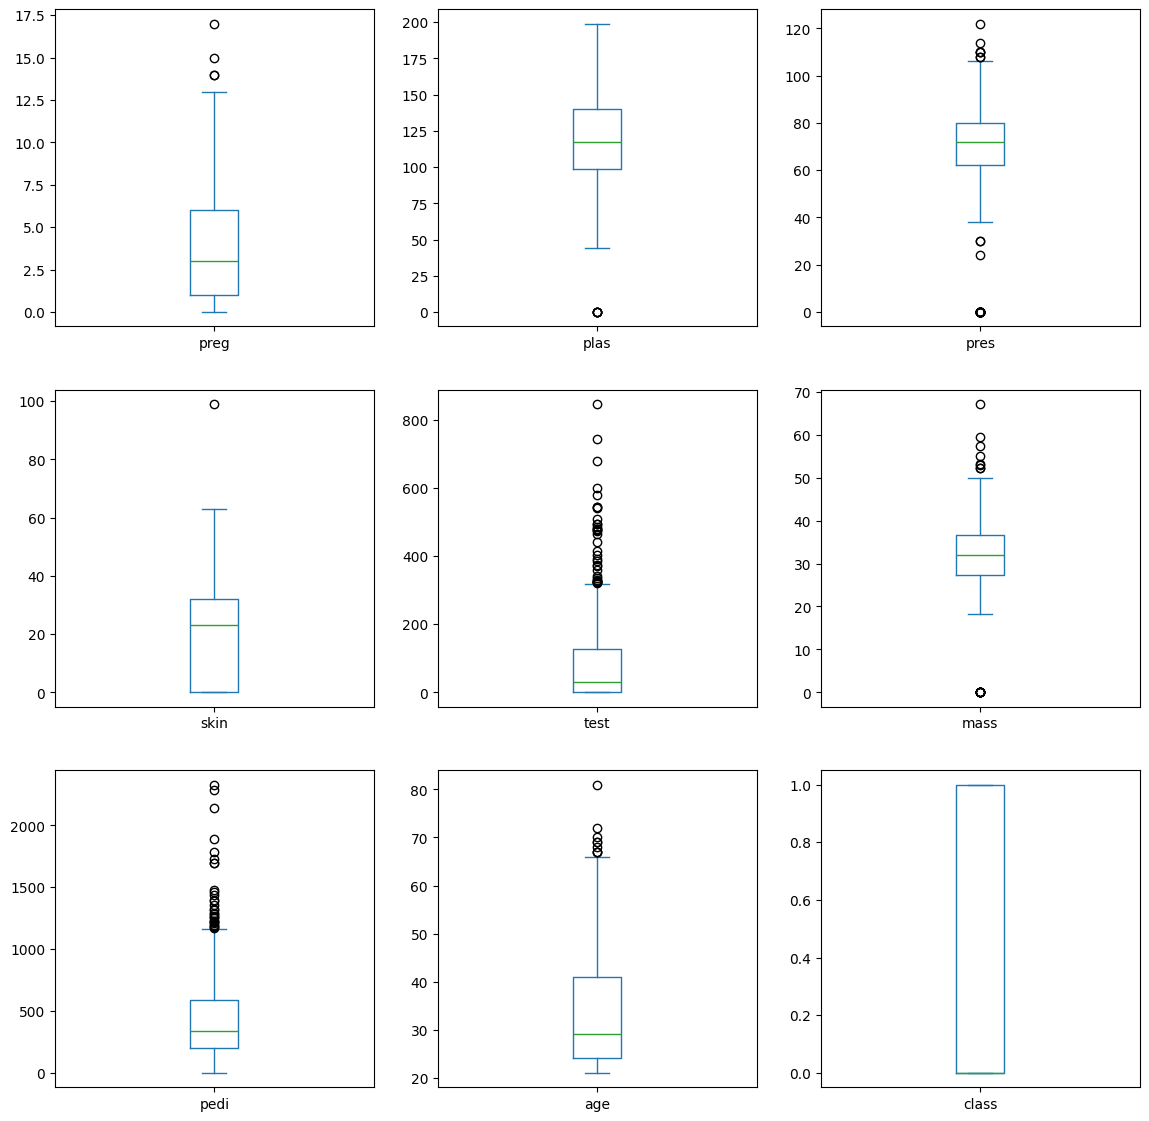

In [8]:
fig=plt.figure(figsize=(14,14))
ax=fig.gca()
data.plot(ax=ax, kind='box', subplots=True,sharex=False,layout=(3,3))
ptl.show()

<Axes: ylabel='class'>

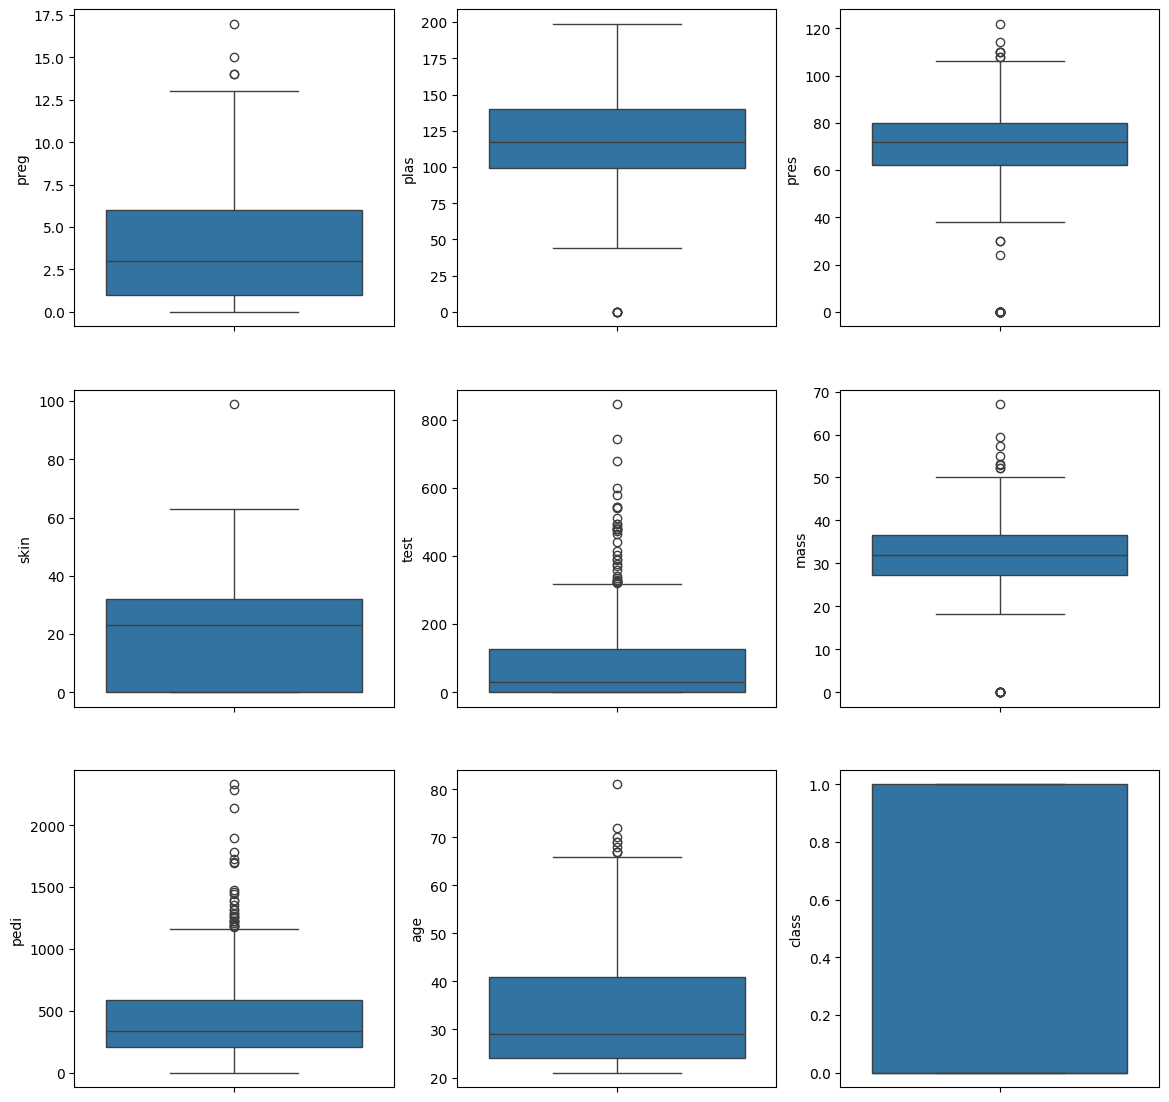

In [9]:
f, axes = plt.subplots(3, 3, figsize = (14,14))
sns.boxplot(data["preg"], ax = axes[0,0])
sns.boxplot(data["plas"], ax = axes[0,1])
sns.boxplot(data["pres"], ax = axes[0,2])
sns.boxplot(data["skin"], ax = axes[1,0])
sns.boxplot(data["test"], ax = axes[1,1])
sns.boxplot(data["mass"], ax = axes[1,2])
sns.boxplot(data["pedi"], ax = axes[2,0])
sns.boxplot(data["age"], ax = axes[2,1])
sns.boxplot(data["class"], ax = axes[2,2])

<div style="text-align: right"> <font size=5>
    <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a>
</font></div>

---

<a id="section3"></a>
# <font color="#004D7F"> 3. Visualización Multivariable</font>

Los gráficos multivariables son los gráficos en los que podemos analizar la relación o interacciones entre atributos. El objetivo es aprender algo acerca de la distribución, la tendencia y la distribución en grupos de datos, generalmente pares de atributos.

<a id="section31"></a>
## <font color="#004D7F">3.1. Matriz de correlación </font>

Podemos ver que la matriz es simétrica, es decir, la parte inferior izquierda de la matriz es la misma que la parte superior derecha. Esto es útil ya que podemos ver dos vistas diferentes en los mismos datos en una parcela. También podemos ver que cada variable está perfectamente correlacionada positivamente entre sí (como era de esperar) en la línea diagonal desde la parte superior izquierda a la parte inferior derecha.

C:\Users\57300\AppData\Local\Temp\ipykernel_19384\3508699949.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(names)
C:\Users\57300\AppData\Local\Temp\ipykernel_19384\3508699949.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names)


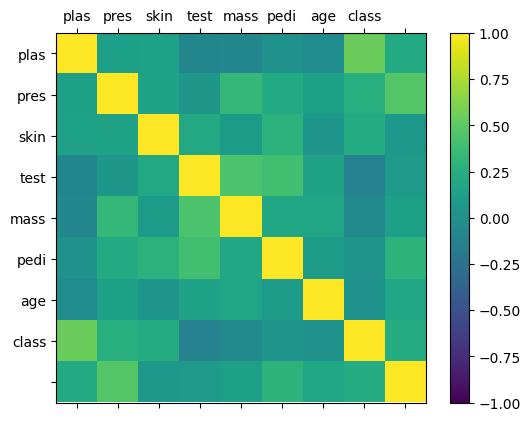

In [10]:
import numpy as np
correlation=data.corr()
fig=plt.figure()
ax=fig.add_subplot()
cax = ax.matshow(correlation,vmin=-1,vmax=1)
fig.colorbar(cax)
ticks=np.arange(0,9,1)
ax.set_yticklabels(names)
ax.set_xticklabels(names)
plt.show()

Al igual que hemos visto antes podemos ver también el gráfico con la librería Seaborn

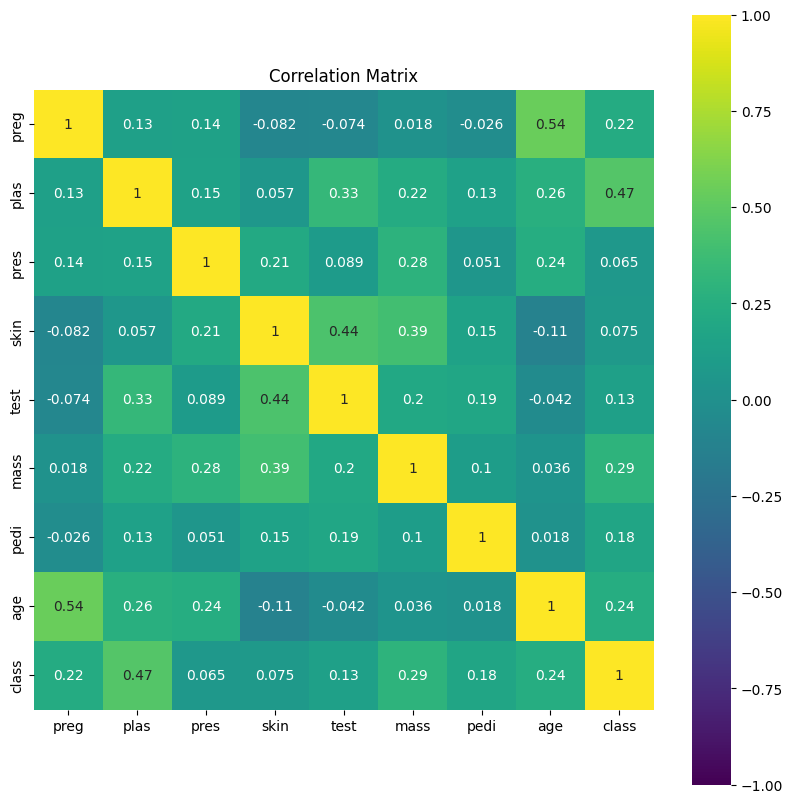

In [11]:
plt.figure(figsize=(10,10))
ax=sns.heatmap(correlation,vmax=1,vmin=-1,square=True,annot=True,cmap='viridis')
plt.title('Correlation Matrix')
plt.show()

<a id="section32"></a>
## <font color="#004D7F">3.2. Matriz de dispersión </font>

Al igual que el diagrama de matriz de correlación anterior, la matriz de diagrama de dispersión es simétrica. Esto es útil para mirar las relaciones por pares desde diferentes perspectivas. Debido a que no tiene mucho sentido dibujar un diagrama de dispersión de cada variable consigo mismo, la diagonal muestra histogramas de cada atributo.

In [12]:
#!pip install pandas.tools

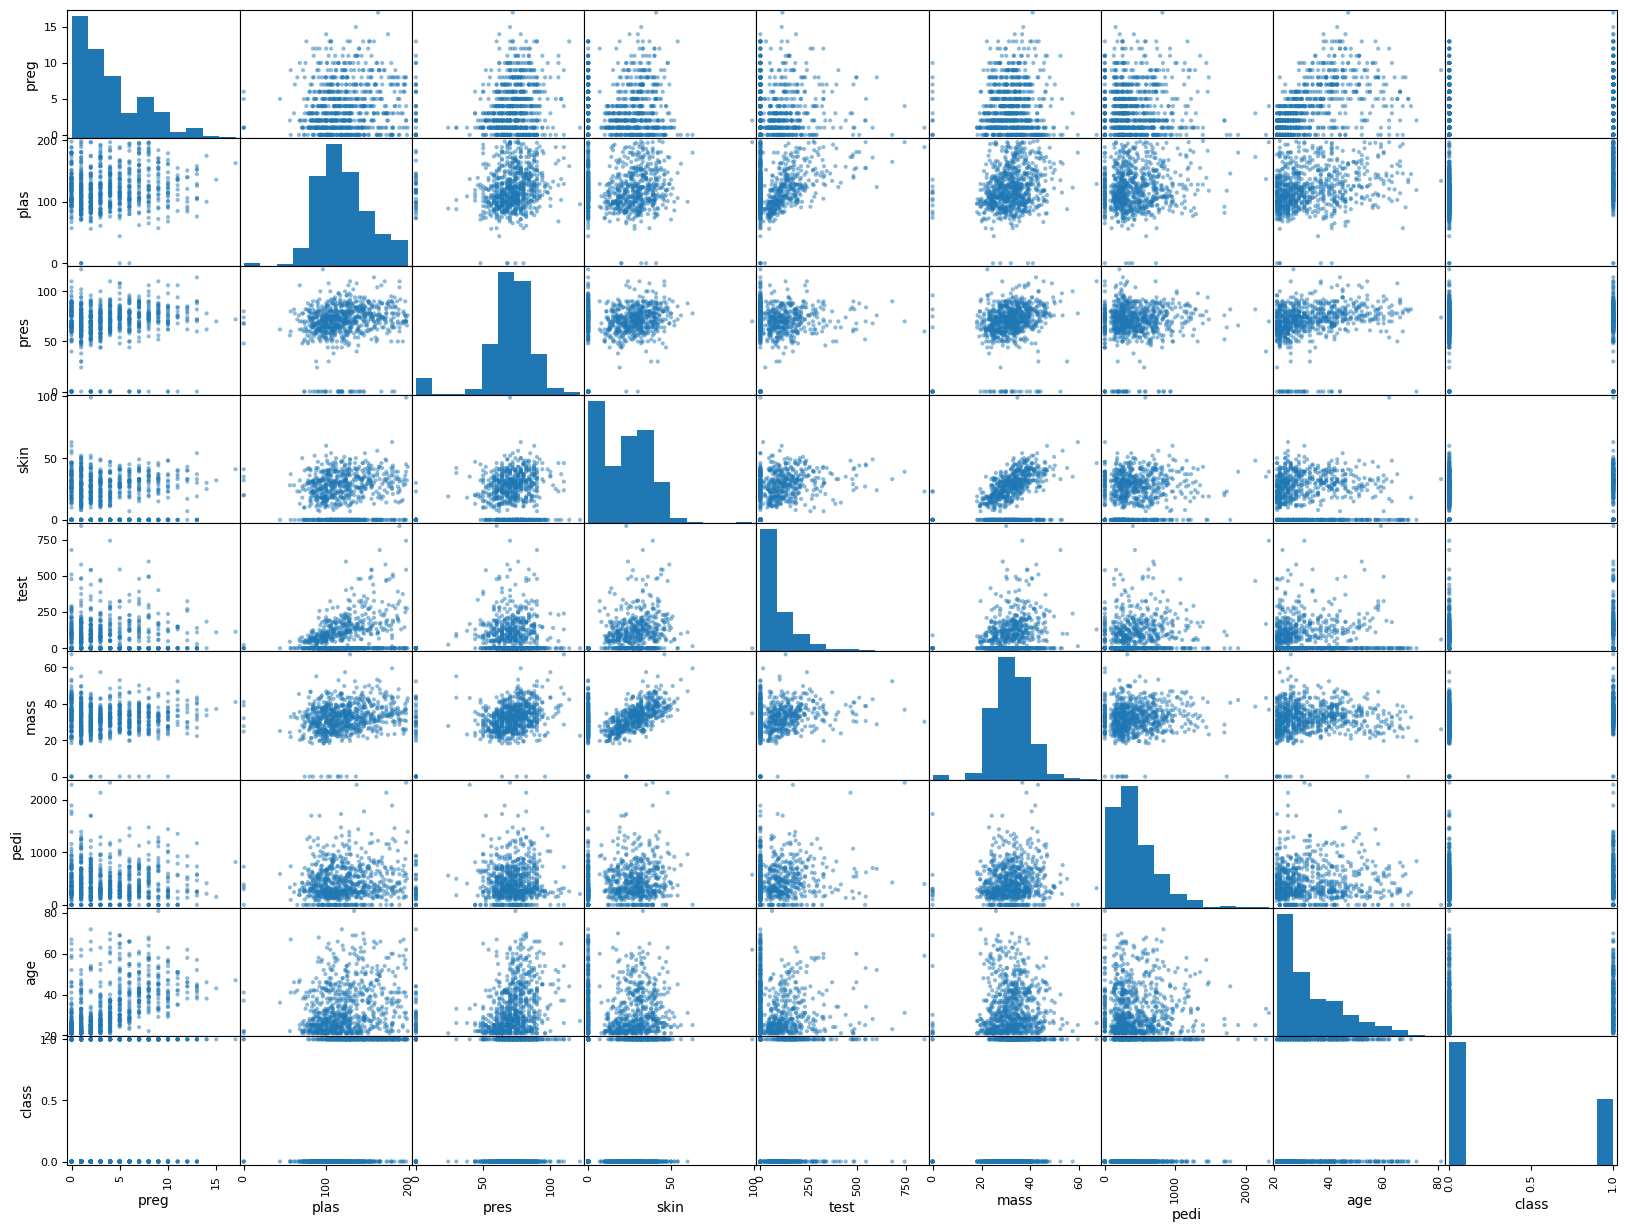

In [13]:
from pandas.plotting import scatter_matrix
plt.rcParams['figure.figsize']=[20,15]
scatter_matrix(data)
plt.show()

Al igual que hemos visto antes podemos ver también el gráfico con la librería Seaborn.

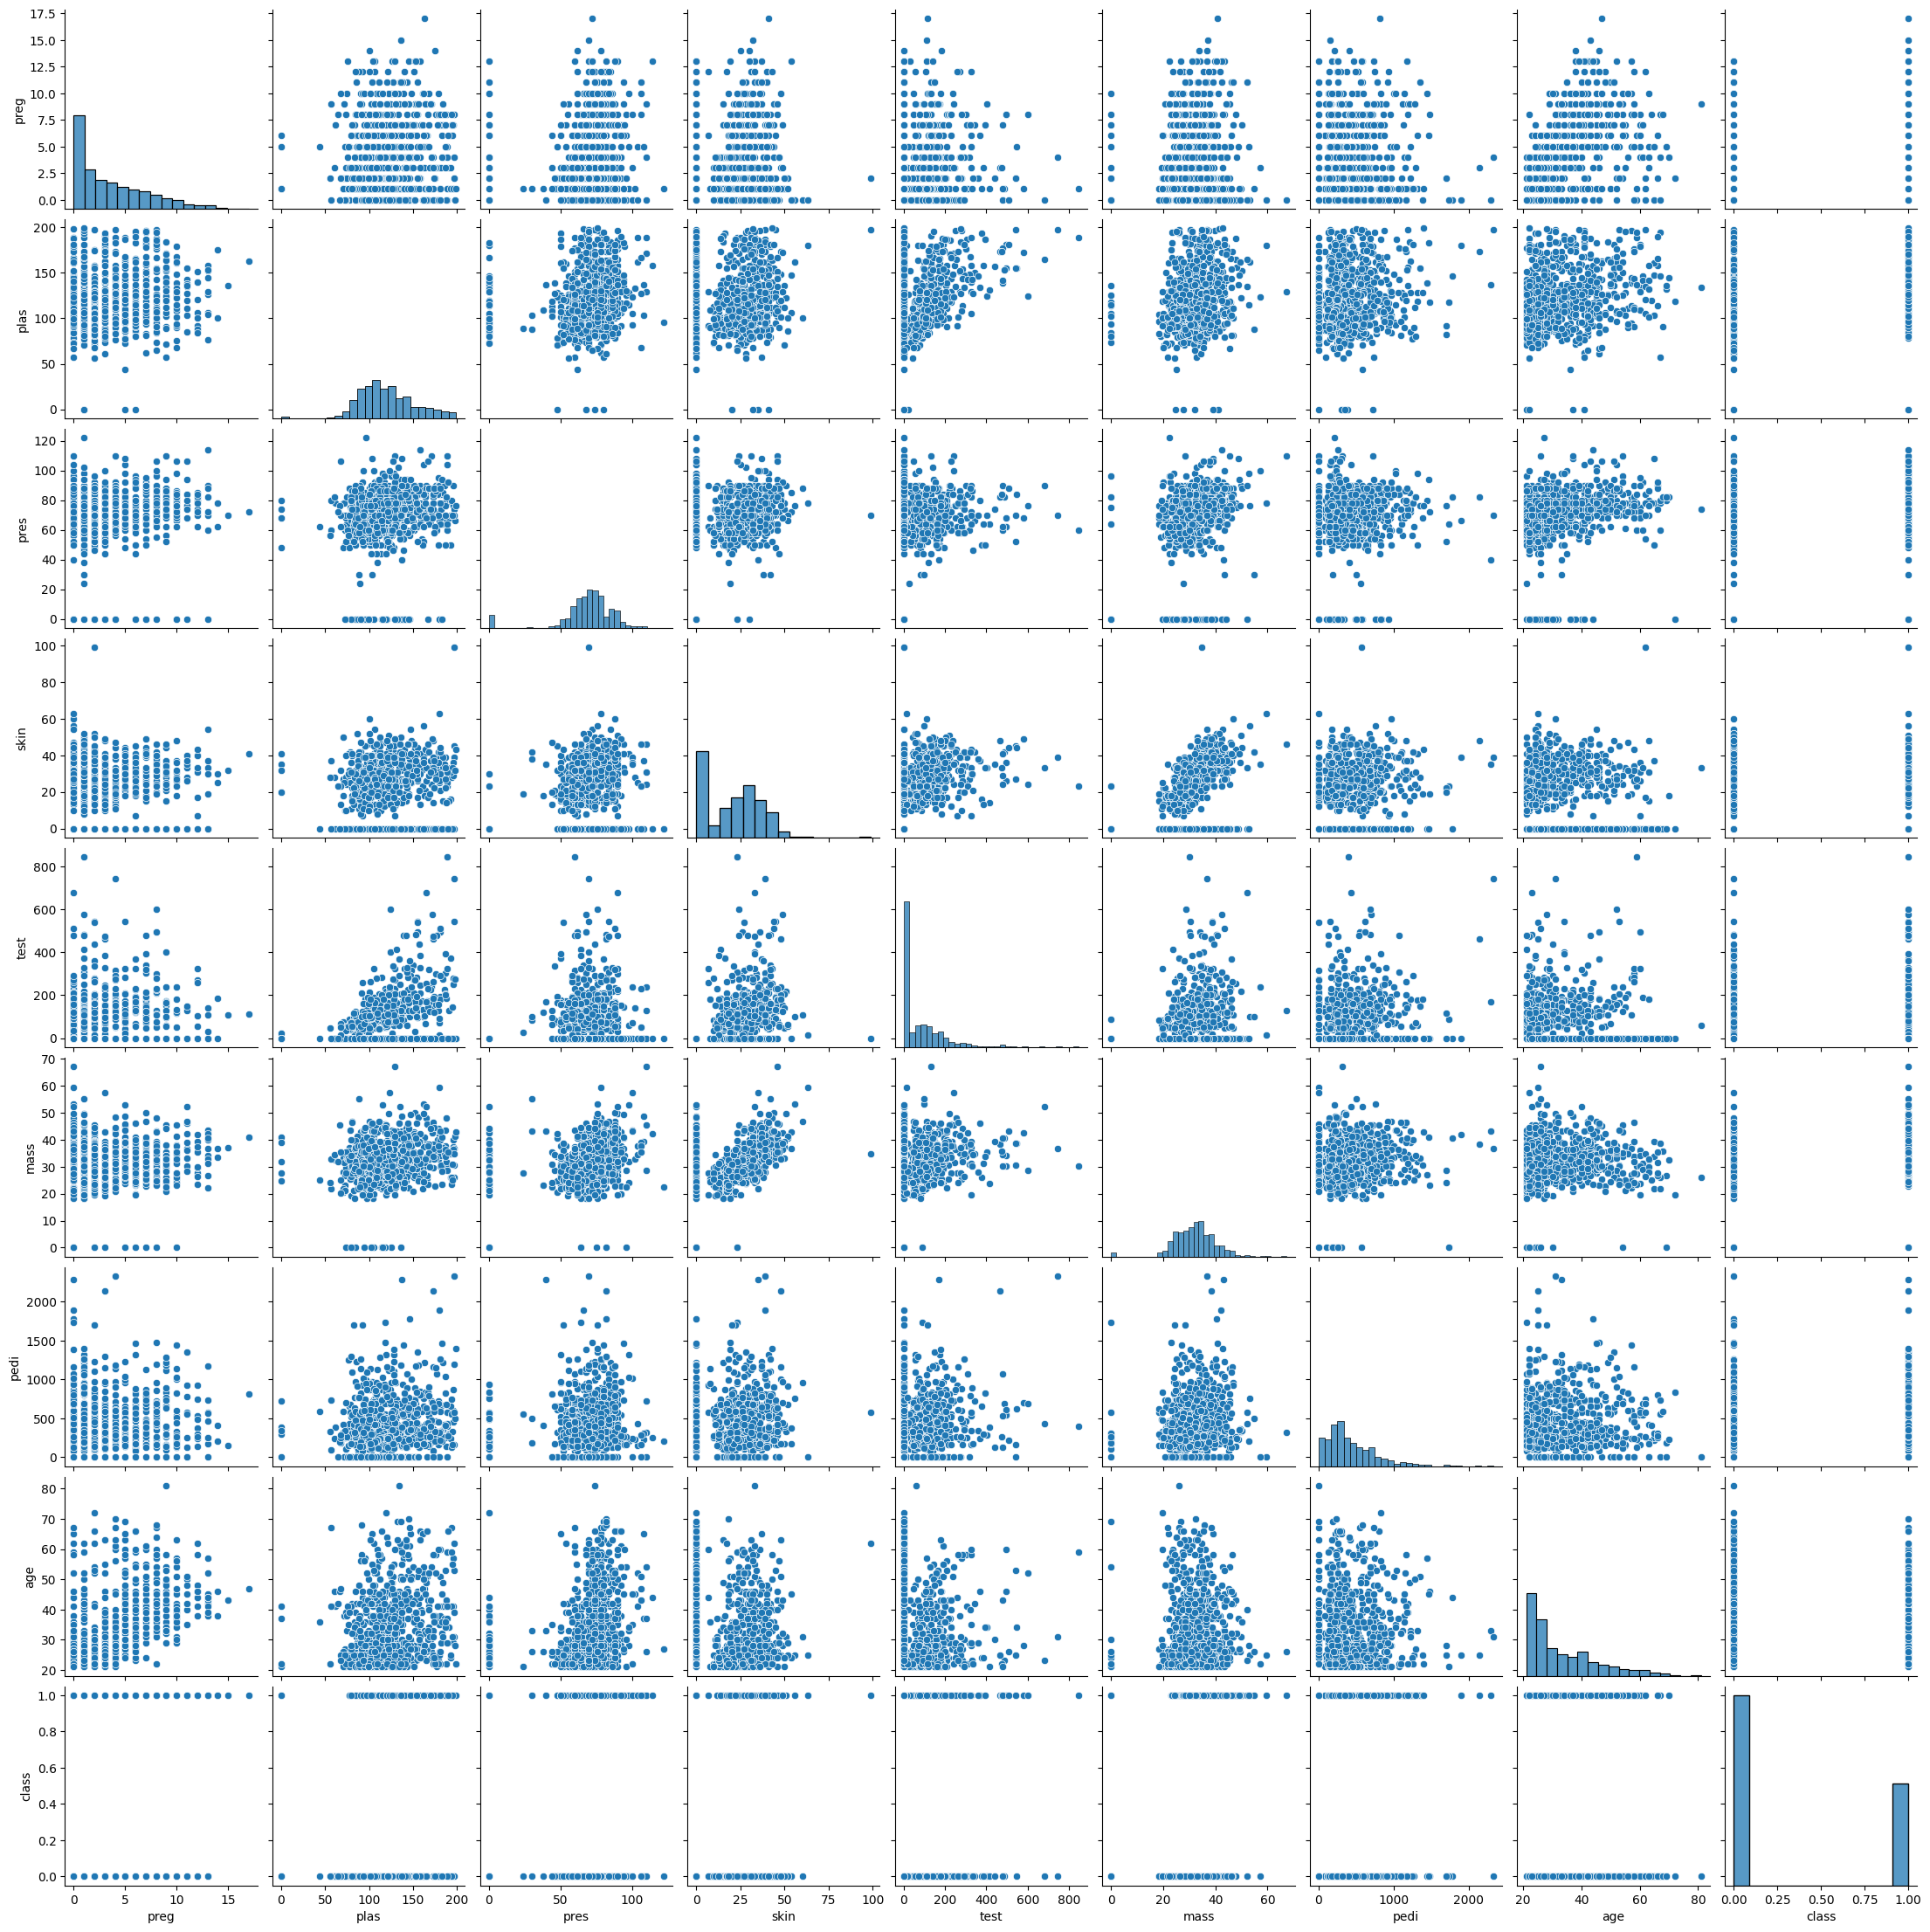

In [14]:
sns.pairplot(data)

<a id="section33"></a>
## <font color="#004D7F">3.3.  Matriz de dispersion por clase </font>

Los puntos en una matriz de diagrama de dispersión pueden ser coloreados por la etiqueta de clase en problemas de clasificación. Esto puede ayudarnos a detectar una separación clara (o no clara) de las clases y quizás a darnos una idea de lo difícil que puede ser el problema.

Al igual que el anterior gráfico los diagramas están dados por la interacción de los pares de atributos pero, en este caso, teniendo en cuenta la etiqueta clase. 

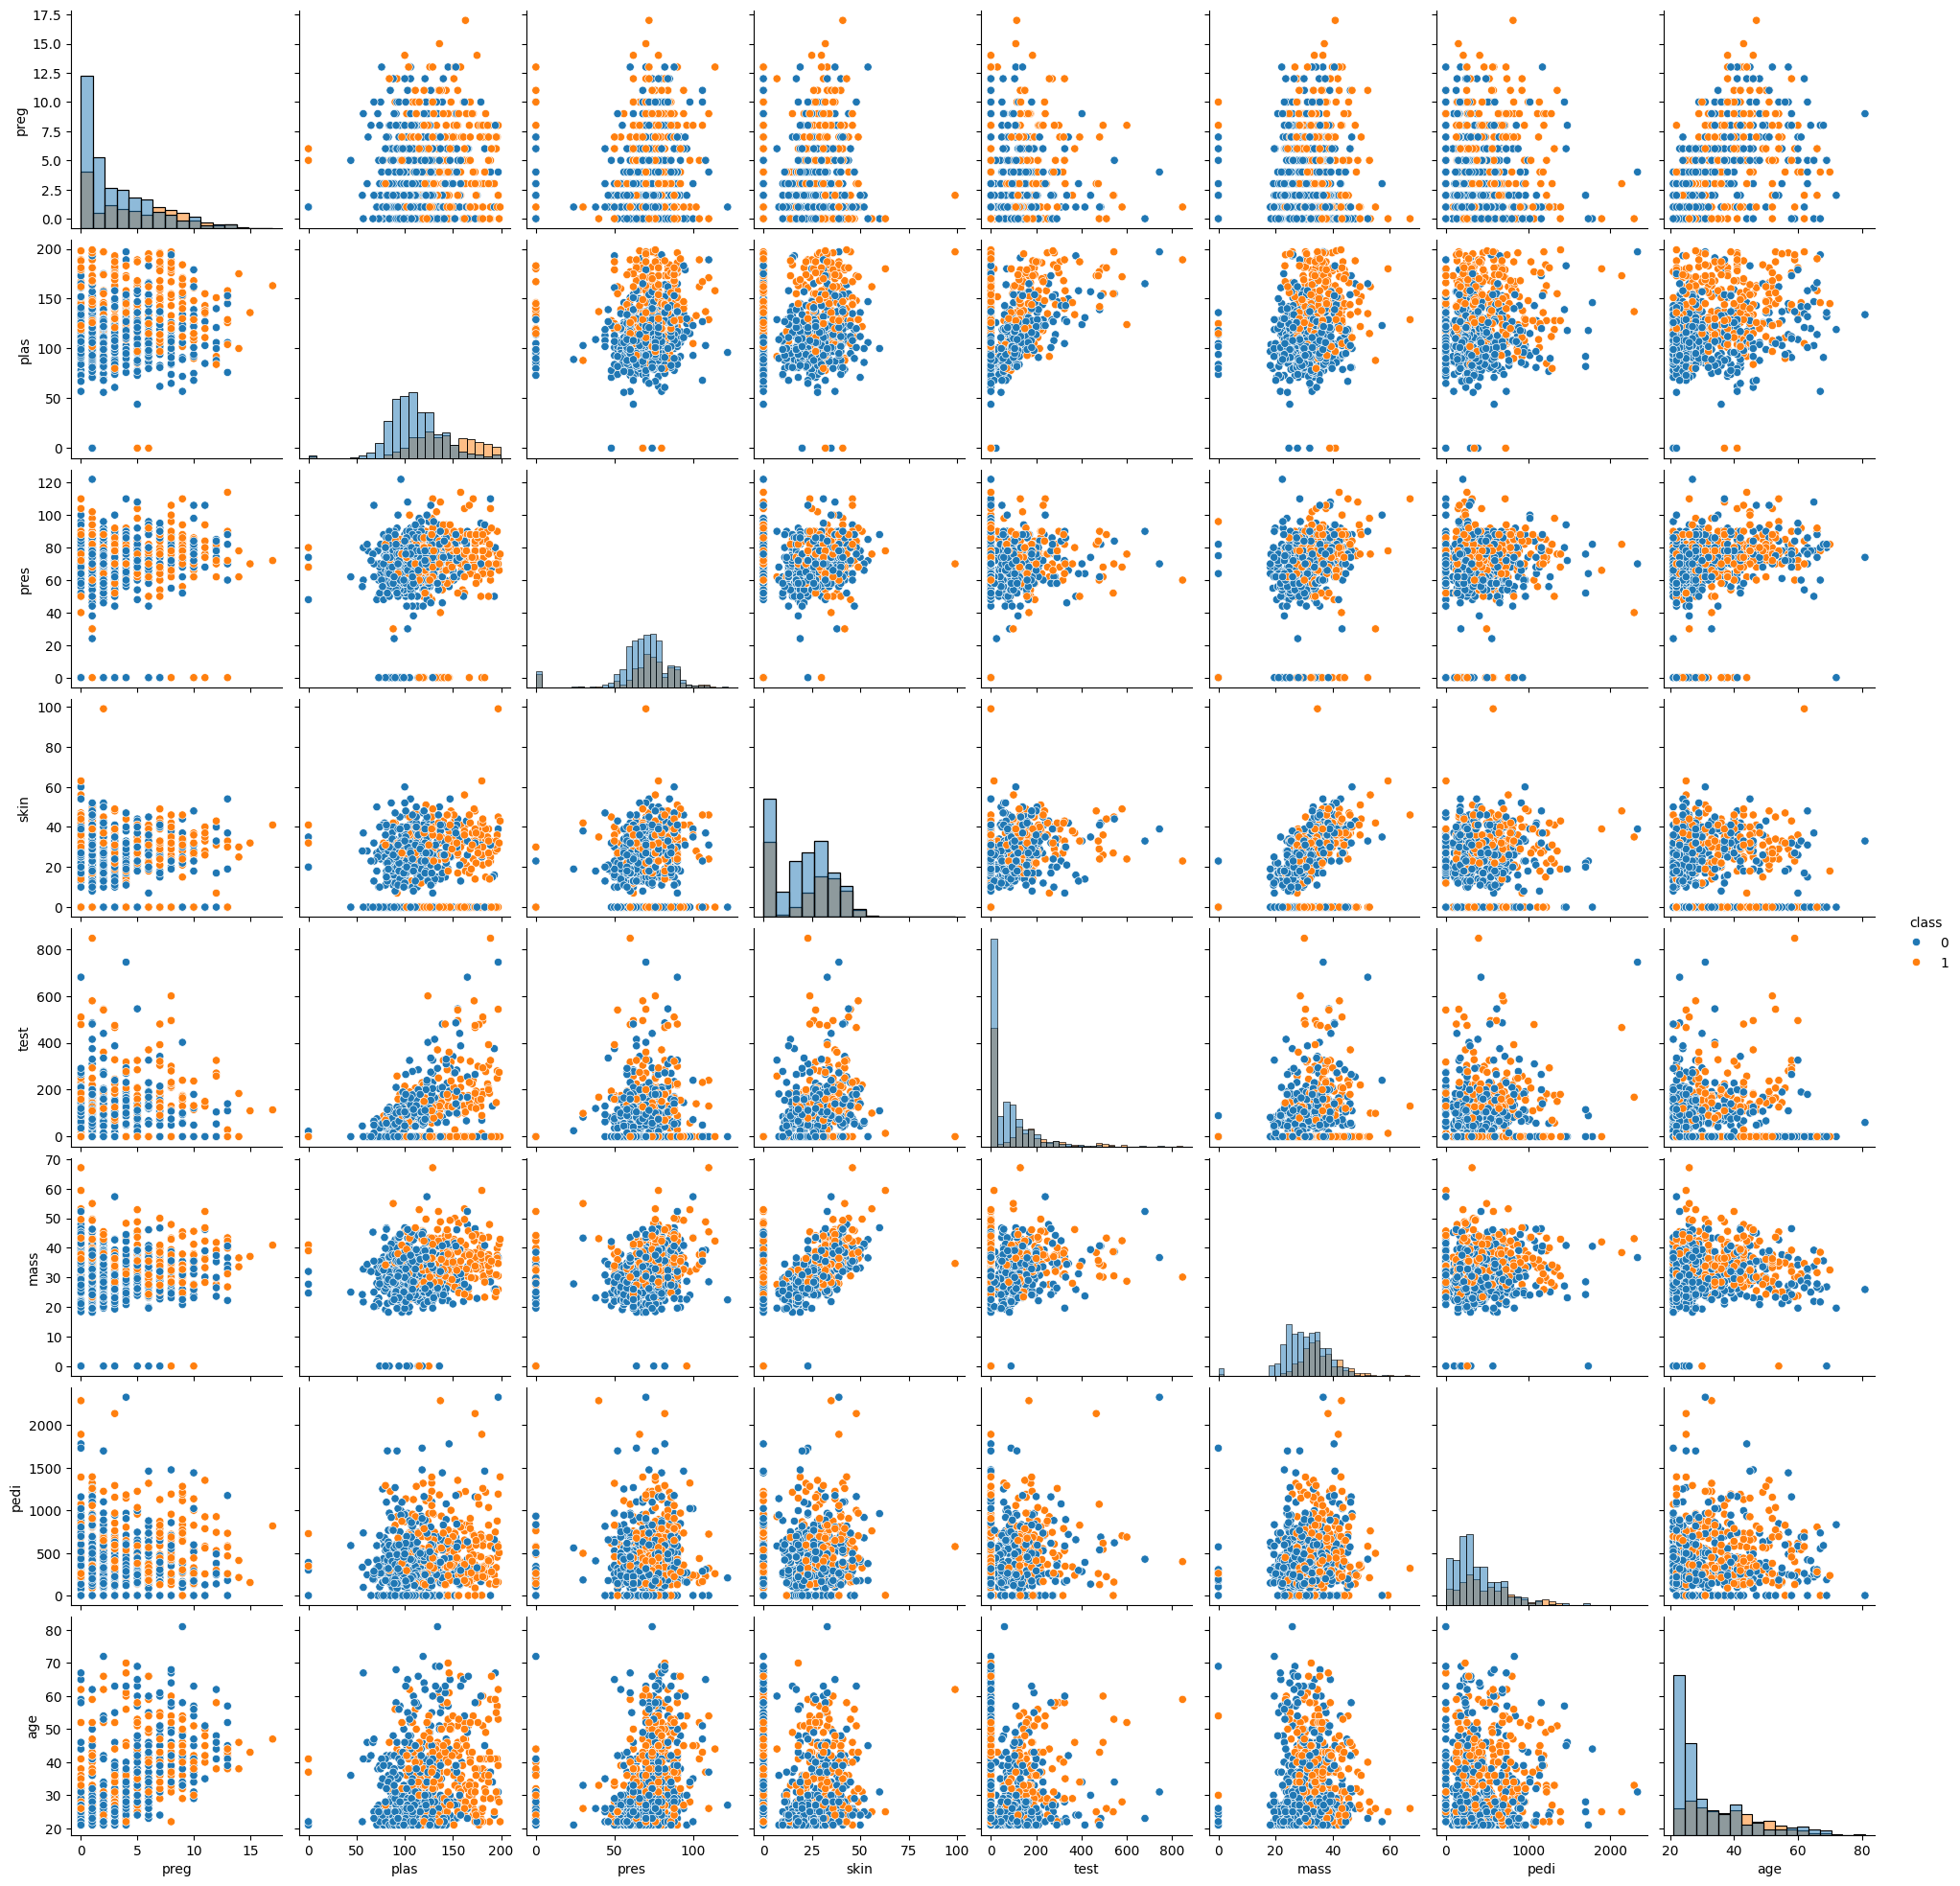

In [15]:
sns.pairplot(data,hue='class',diag_kind='hist')

<a id="section34"></a>
## <font color="#004D7F">3.4. Boxplots por clase </font>

Este tipo de gráficos nos ayudan a comprender la superposición y la separación de la clase con los atributos características, por ejemplo en el gráfico podemos observar una buena separación de la clase _Setosa_ para el atributo _Petal.lenght_

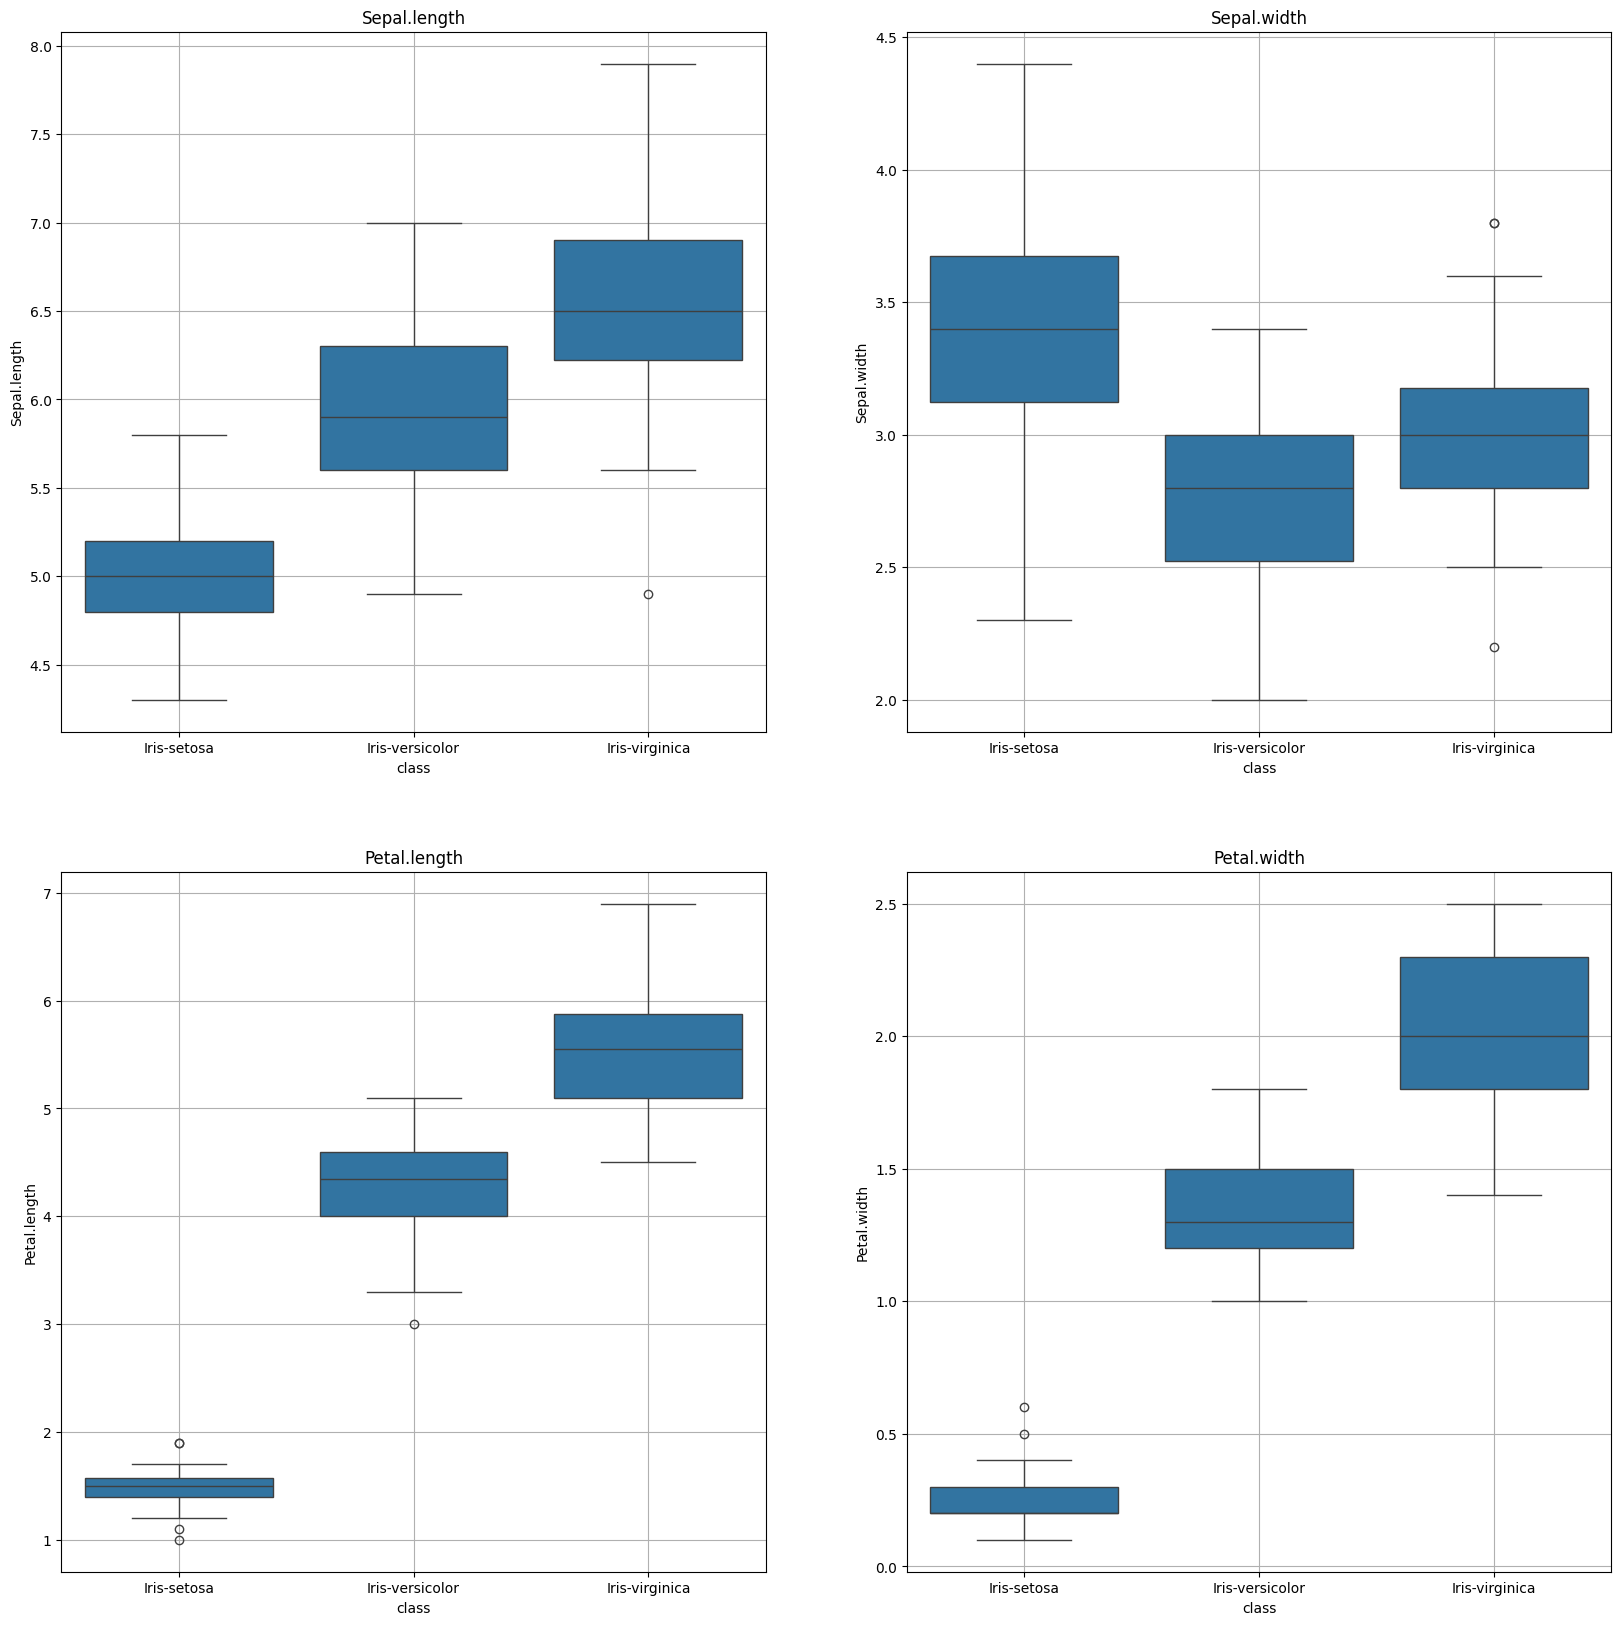

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar los datos
filename = 'data/iris.data.csv'
names = ['Sepal.length', 'Sepal.width', 'Petal.length', 'Petal.width', 'class']
data = pd.read_csv(filename, names=names)

# Crear los subplots con el tamaño especificado
fig, axs = plt.subplots(2, 2, figsize=(20, 20))

# Primer subplot
sns.boxplot(x='class', y='Sepal.length', data=data, ax=axs[0, 0])
axs[0, 0].set_title('Sepal.length')
axs[0, 0].grid(True)

# Segundo subplot
sns.boxplot(x='class', y='Sepal.width', data=data, ax=axs[0, 1])
axs[0, 1].set_title('Sepal.width')
axs[0, 1].grid(True)

# Tercer subplot
sns.boxplot(x='class', y='Petal.length', data=data, ax=axs[1, 0])
axs[1, 0].set_title('Petal.length')
axs[1, 0].grid(True)

# Cuarto subplot
sns.boxplot(x='class', y='Petal.width', data=data, ax=axs[1, 1])
axs[1, 1].set_title('Petal.width')
axs[1, 1].grid(True)

# Mostrar los gráficos
plt.show()


<div style="text-align: right"> <font size=5>
    <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a>
</font></div>

---

<div style="text-align: right"> <font size=6><i class="fa fa-coffee" aria-hidden="true" style="color:#004D7F"></i> </font></div>